# Price Optimization

**This project aims to check the impact of promotions to demand and find the optimal price that guarantees the highest profit and substantial amount of demand**

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("train.csv")
meal_df = pd.read_csv("meal_info.csv")

In [3]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [4]:
df.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


In [6]:
df["Discount_percent"] = df.apply(lambda x: int((x["base_price"] - x["checkout_price"]) / x["base_price"] * 100), axis=1)

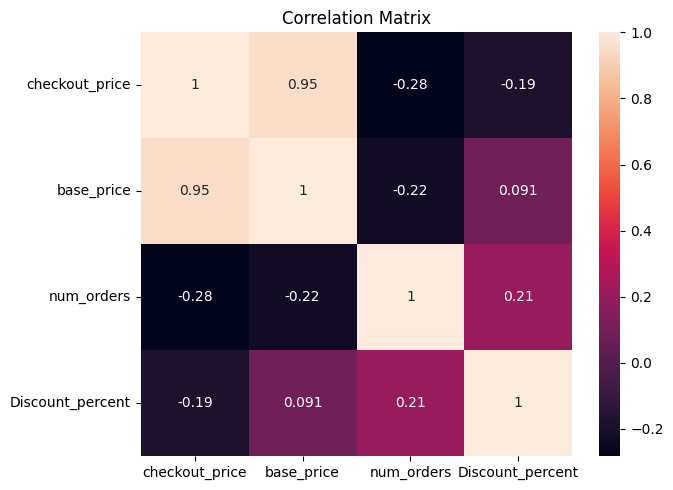

In [7]:
# Check value correlation

num_df = df[["checkout_price", "base_price", "num_orders", "Discount_percent"]]

df_corr = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr, annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

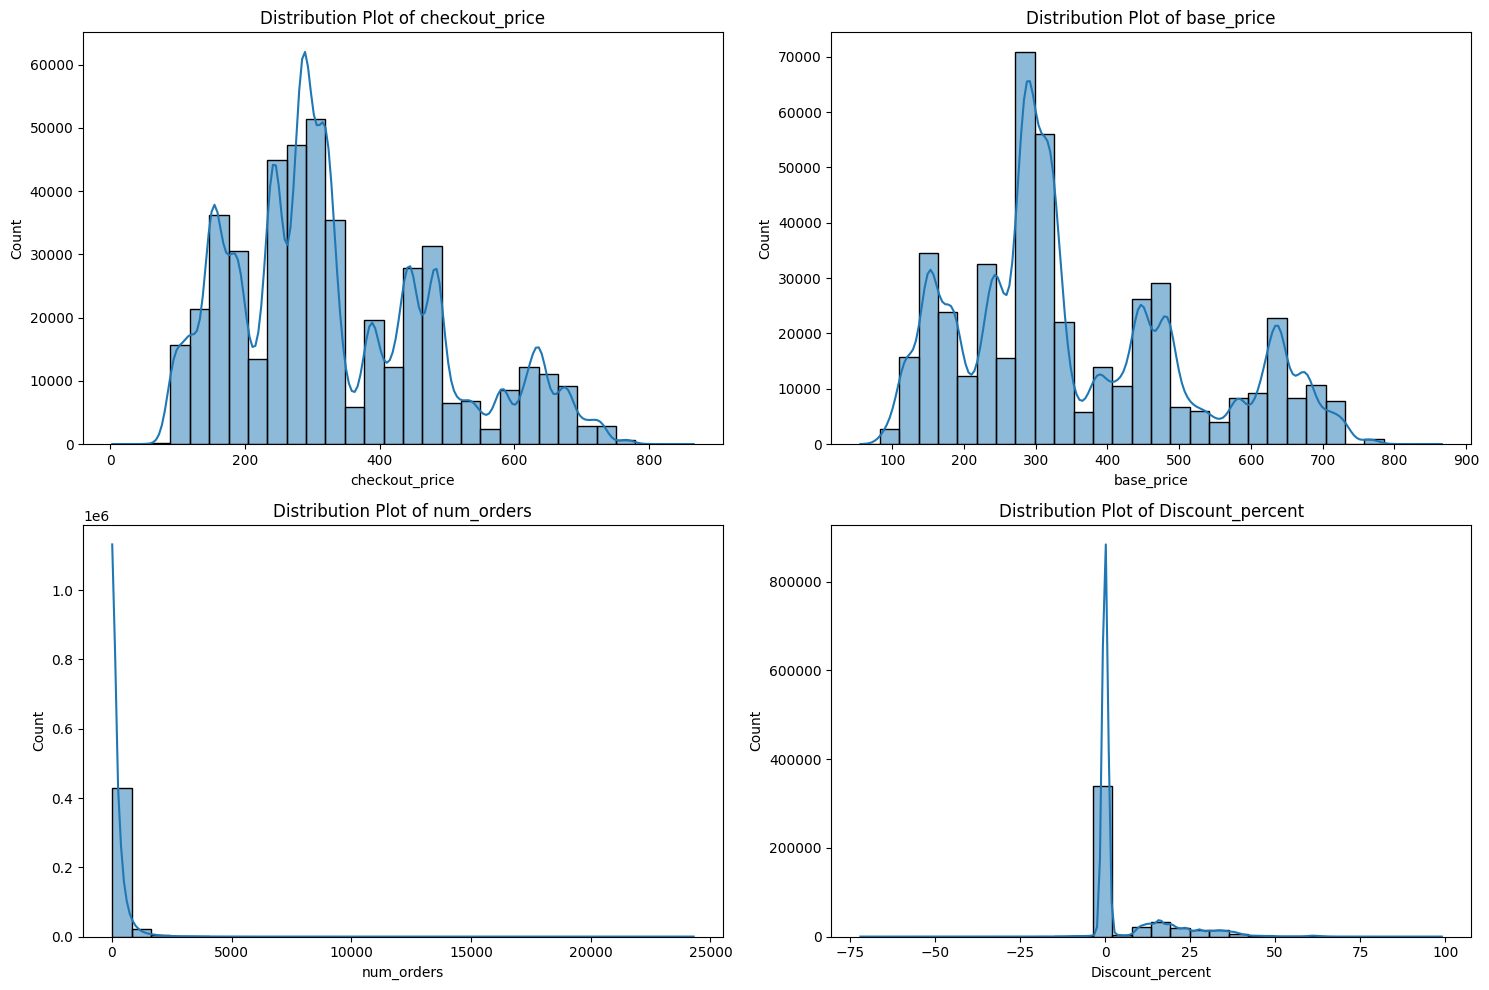

In [8]:
# Checking distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ind, col in enumerate(num_df.columns):
    row = ind//2
    col_idx = ind%2
    sns.histplot(data=num_df, x=col, bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"Distribution Plot of {col}")

plt.tight_layout()
plt.show()

In [9]:
# Clean for outliers
Q1 = df["Discount_percent"].quantile(0.25)
Q3 = df["Discount_percent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

df = df[
    (df["Discount_percent"] >= lower_bound) &
    (df["Discount_percent"] <= upper_bound)
]



In [10]:
# Map meal_df contents to df

df = df.merge(
    meal_df[["meal_id", "category", "cuisine"]],
    on="meal_id",
    how="left"
)

In [11]:
df

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,Discount_percent,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,10,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,0,Beverages,Thai
3,1448490,1,55,2631,243.50,242.50,0,0,40,0,Beverages,Indian
4,1270037,1,55,1248,251.23,252.23,0,0,28,0,Beverages,Indian
...,...,...,...,...,...,...,...,...,...,...,...,...
374358,1010438,145,61,2704,321.13,320.13,0,0,67,0,Other Snacks,Thai
374359,1116711,145,61,2492,455.93,455.93,0,0,42,0,Desert,Indian
374360,1271326,145,61,1543,484.09,484.09,0,0,68,0,Desert,Indian
374361,1062036,145,61,2304,482.09,482.09,0,0,42,0,Desert,Indian


In [12]:
df["homepage_featured"] = np.where(df["homepage_featured"] > 0, True, False)
df["emailer_for_promotion"] = np.where(df["emailer_for_promotion"] > 0, True, False)

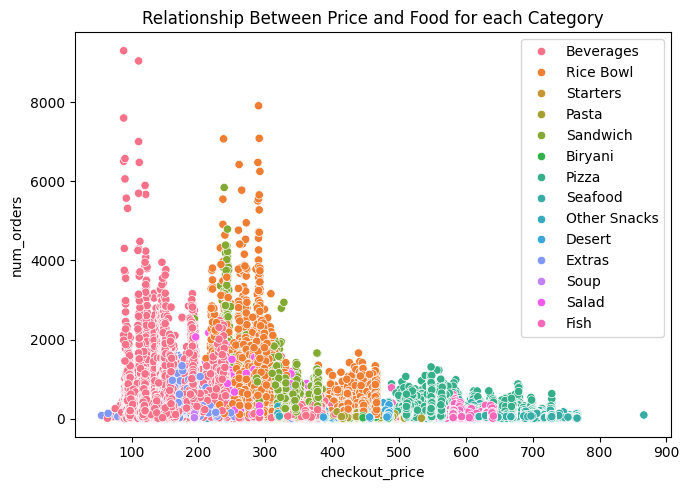

In [13]:
# check the demand responsiveness to price for different kind of category

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="checkout_price", y="num_orders", hue="category")
plt.legend()
plt.title("Relationship Between Price and Food for each Category")
plt.tight_layout()
plt.show()

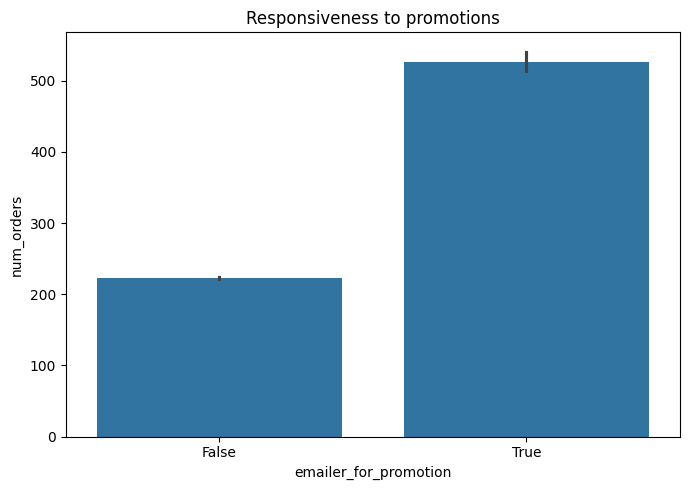

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="emailer_for_promotion", y="num_orders")
plt.title("Responsiveness to promotions")
plt.tight_layout()
plt.show()

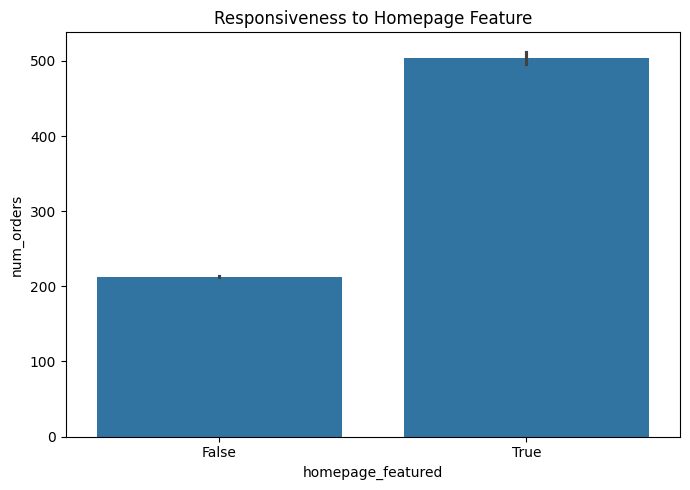

In [15]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="homepage_featured", y="num_orders")
plt.title("Responsiveness to Homepage Feature")
plt.tight_layout()
plt.show()

# Advanced Feature Preprocessing and Modelling

In [16]:
df.drop(["id", "base_price"], axis=1, inplace=True)

In [17]:
cat_col = ["center_id", "meal_id", "emailer_for_promotion", "homepage_featured", "category",
           "cuisine"]

num_col = [i for i in df.columns if i not in cat_col]
num_col.remove('num_orders')

In [18]:
## Seperate data and split

# Reduce data
df = df.sample(frac=1)[:50_000]

X = df.drop('num_orders', axis=1)
y = df['num_orders']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), cat_col),
                  ('num', StandardScaler(), num_col)
                 ])

transformed_data = preprocessor.fit_transform(X_train).toarray()

all_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_col)

all_cols = list(all_cat_cols) + num_col

X_train_trans = pd.DataFrame(transformed_data, columns=all_cols)

In [20]:
X_test_array = preprocessor.transform(X_test).toarray()
X_train_array = np.array(X_train_trans)

In [21]:
y_test.mean()

np.float64(232.5989)

In [22]:
model = RandomForestRegressor()
model.fit(X_train_array, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
print(model.score(X_train_array, y_train))
print(model.score(X_test_array, y_test))

0.9730272217916285
0.8194100908107729


# Model Evaluation

In [24]:
y_pred = model.predict(X_test_array)

In [25]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MSE: 16299.05272079
MAE: 68.632937
RMSE: 127.66774346243454


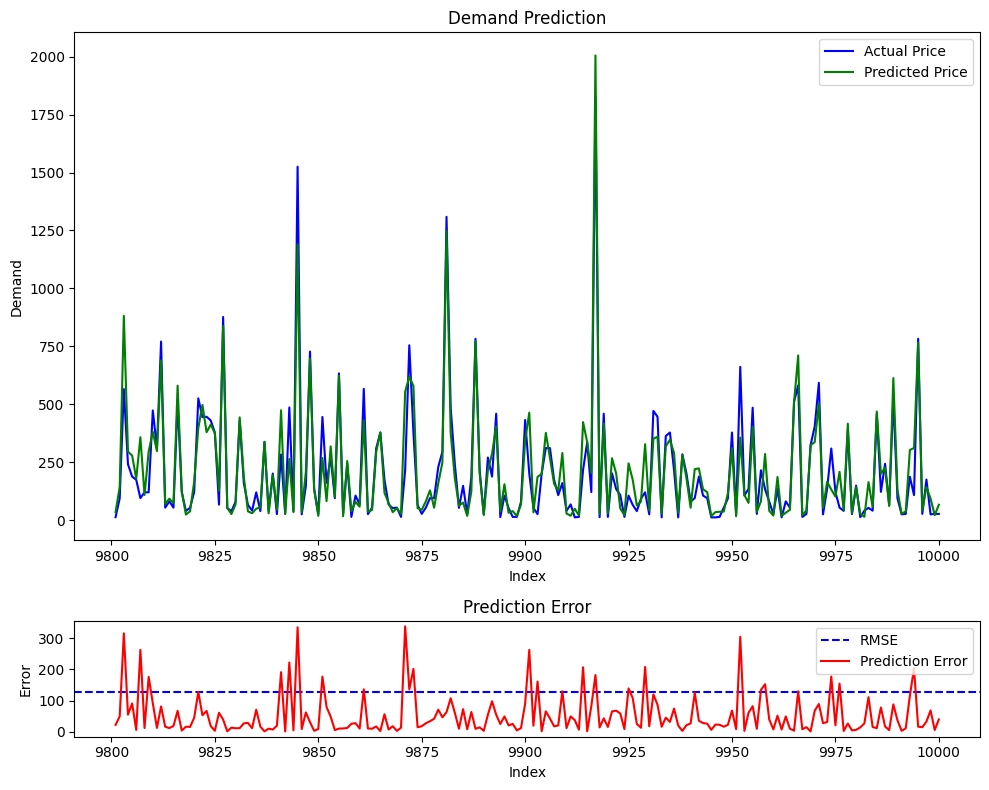

In [26]:
index = [i for i in range(len(y_pred) + 1)]


fig = plt.figure(figsize=(10, 8))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(index[-200:],  y_test[-200:], color='blue', label="Actual Price")
ax1.plot(index[-200:],  y_pred[-200:], color='green', label="Predicted Price")
plt.legend()
plt.title(f"Demand Prediction")
plt.xlabel("Index")
plt.ylabel("Demand")

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(rmse, color = 'blue', linestyle='--', label='RMSE')
ax2.plot(index[-200:], abs(y_test - y_pred)[-200:], 'r', label='Prediction Error')
ax2.legend()
plt.title("Prediction Error")
plt.xlabel("Index")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

In [27]:
# Train on all data

X_full = preprocessor.transform(X).toarray()
model.fit(X_full, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Save Data and Artifacts

In [28]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(model, "optim_model.pkl")

['optim_model.pkl']

In [29]:
test_data = np.array([y_pred[:200], y_test[:200]])
np.save("Test_data.npy", test_data)